# Install libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from firthlogist import FirthLogisticRegression
from sklearn.utils.validation import check_X_y

# To resolve the patched_validate issue (Required for Firth in Python 3.10 / newer scikit-learn)

In [2]:
def patched_validate(self, X, y, **kwargs):
    return check_X_y(X, y, **kwargs)
FirthLogisticRegression._validate_data = patched_validate

# Opening cleaned PAROS dataset

In [3]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


In [4]:
print(df.columns.tolist())


['Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance arrived at ED', 'Arrest witnessed by', 'Bystander CPR', 'DA-CPR', 'First CPR initiated by', 'Bystander AED applied', 'Resuscitation attempted by EMS/Private ambulance', 'First arrest rhythm', 'Prehospital Defibrillation', 'Time of first shock given', 'Time of first shock Unknown', 'Defibrillation performed by - First Responder', 'Defibrillation performed by - Ambulance Crew', 'Defibrillation performed by - Bystander - Healthcare provider', 'Defibrillation performed by - Bystander - Lay Person', 'Defibrillation performed by - Bystander - Family', 'Other', 'R

# Define Binary Outcome (Survival to 30 Days)


In [5]:
# 1. Combine all possible outcome columns into one searchable string
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']

# If any of these columns don't exist in your current slice, only use the ones that do
available_cols = [col for col in outcome_cols if col in df.columns]
df['Outcome_String'] = df[available_cols].astype(str).agg(' '.join, axis=1)

# 2. Use the broad Regex to catch all variations of survival
survival_regex = r'Discharged Alive|Remains in hospital at 30th day|Survived to discharge'
df['Survival_Binary'] = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True).astype(int)

# 3. Verify the number (This should hit your ~297 target from the N=2076 cohort)
print(f"Total Survivors: {df['Survival_Binary'].sum()}")

# Optional Diagnostic: See what strings actually exist if it still doesn't work
if df['Survival_Binary'].sum() == 0:
    print("\nDiagnostic - Unique values in outcome column:")
    print(df['Outcome of patient'].unique())

Total Survivors: 349


# Define Primary Predictor (Bystander AED applied)
- We map any variation of 'Yes' or '1' to 1, and everything else to 0

In [6]:
aed_col = 'Bystander AED applied'
df.loc[:, 'AED_Applied_Binary'] = df[aed_col].astype(str).str.contains('Yes|Applied|1', case=False, na=False).astype(int)

In [7]:
def find_optimal_tau(df, time_col, outcome_col, tau_candidates):
    """
    Runs a profile likelihood grid search using piecewise Firth Logistic Regression.
    Returns the tau that maximizes the log-likelihood.
    """
    df_clean = df.dropna(subset=[time_col, outcome_col]).copy()
    y = df_clean[outcome_col].values
    
    best_tau = None
    max_ll = -np.inf
    
    for tau in tau_candidates:
        # Create continuous piecewise features
        X_early = np.minimum(df_clean[time_col], tau)
        X_late = np.maximum(0, df_clean[time_col] - tau)
        
        # VARIANCE GATEKEEPER: Skip tau if it creates constant columns (prevents Singular Matrix Errors)
        if np.std(X_early) == 0 or np.std(X_late) == 0:
            continue
            
        X = np.column_stack((X_early, X_late))
        
        try:
            model = FirthLogisticRegression(max_iter=500, fit_intercept=True)
            model.fit(X, y)
            
            preds = model.predict_proba(X)
            eps = 1e-15
            preds = np.clip(preds, eps, 1 - eps) 
            ll = np.sum(y * np.log(preds) + (1 - y) * np.log(1 - preds))
            
            if ll > max_ll:
                max_ll = ll
                best_tau = tau
                
        except Exception:
            continue
            
    return best_tau

In [8]:
# ==========================================
# STEP 1: PREPARATION & GROUND TRUTH
# ==========================================
rq2_df = df[df['Time_to_Defib'].notna()].copy()
rq2_df['Survived'] = rq2_df['Outcome of patient'].str.contains('Discharged Alive', case=False, na=False).astype(int)
tau_grid = np.arange(1.0, 15.1, 0.1)

print("Calculating Ground Truth Tau (Continuous Data)...")
ground_truth_tau = find_optimal_tau(rq2_df, 'Time_to_Defib', 'Survived', tau_grid)

Calculating Ground Truth Tau (Continuous Data)...


In [9]:
# ==========================================
# STEP 2: BINNING DISTORTION CALCULATION
# ==========================================
bin_sizes = [1, 2, 3, 4, 5]
discovered_taus = []

for bin_sz in bin_sizes:
    print(f"Analyzing {bin_sz}-minute bins...")
    df_temp = rq2_df.copy()
    bins = np.arange(0, df_temp['Time_to_Defib'].max() + bin_sz + 1, bin_sz)
    df_temp['Time_Bin'] = pd.cut(df_temp['Time_to_Defib'], bins=bins, right=False)
    df_temp['Binned_Time'] = df_temp['Time_Bin'].apply(lambda x: x.mid).astype(float)
    
    binned_tau = find_optimal_tau(df_temp, 'Binned_Time', 'Survived', tau_grid)
    discovered_taus.append(binned_tau)

Analyzing 1-minute bins...
Analyzing 2-minute bins...
Analyzing 3-minute bins...
Analyzing 4-minute bins...
Analyzing 5-minute bins...


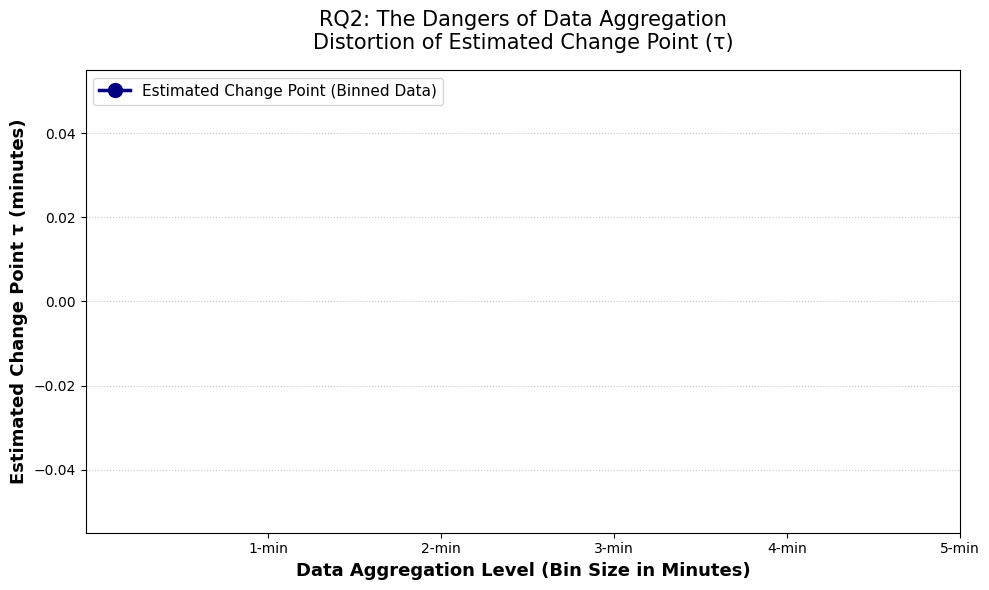

In [10]:
# ==========================================
# STEP 3: UPDATED PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the distortion curve
plt.plot(bin_sizes, discovered_taus, marker='o', markersize=10, linestyle='-', linewidth=2.5, 
         color='navy', label='Estimated Change Point (Binned Data)')

# Plot Ground Truth Line
if ground_truth_tau is not None:
    plt.axhline(y=ground_truth_tau, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Ground Truth Threshold ({ground_truth_tau:.1f} min)')

# Annotate Distortion Percentages
for i, txt in enumerate(discovered_taus):
    if pd.notna(txt):
        if ground_truth_tau:
            distortion = ((txt - ground_truth_tau) / ground_truth_tau) * 100
            sign = "+" if distortion > 0 else ""
            label = f"{txt:.1f}m\n({sign}{distortion:.1f}%)"
        else:
            label = f"{txt:.1f}m"
        
        plt.annotate(label, (bin_sizes[i], discovered_taus[i]), 
                     textcoords="offset points", xytext=(0,15), ha='center',
                     fontsize=10, fontweight='bold', color='#2c3e50',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Formatting
plt.title('RQ2: The Dangers of Data Aggregation\nDistortion of Estimated Change Point (τ)', fontsize=15, pad=15)
plt.ylabel('Estimated Change Point τ (minutes)', fontsize=13, fontweight='bold')
plt.xlabel('Data Aggregation Level (Bin Size in Minutes)', fontsize=13, fontweight='bold')
plt.xticks(bin_sizes, [f"{b}-min" for b in bin_sizes])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(fontsize=11, loc='upper left', frameon=True)
plt.tight_layout()

# This command is what actually forces Jupyter to display the graph!
plt.show()